# Airfoil Cl Prediction — ResNet-18 Training
**Week 3 — Predicting Aerodynamic Coefficients from 2D Geometries using CNNs**

This notebook:
1. Mounts Google Drive and loads the airfoil image + CSV dataset
2. Builds a PyTorch DataLoader pairing each image with its Cl at AoA = 5°
3. Loads a pretrained ResNet-18 and modifies the final layer for regression
4. Trains the model using Mean Squared Error (MSE) loss
5. Plots Actual XFOIL Lift vs Neural Network Predicted Lift

## Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
RESULTS_DIR = '/content/drive/MyDrive/experiments'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Set paths to your uploaded folders
IMG_DIR = '/content/drive/MyDrive/images'
CSV_DIR = '/content/drive/MyDrive/1e6'

print(f'Images: {len(os.listdir(IMG_DIR))} files')
print(f'CSVs:   {len(os.listdir(CSV_DIR))} files')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images: 1573 files
CSVs:   1573 files


## Step 2 — Install & Import Libraries

In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 3 — Dataset: Pair Images with Cl Values

In [ ]:
RUN_NAME = 'run13_dropout0.5_seed42'

TARGET_AOA = 5.0
TOLERANCE  = 0.3

def get_cl_at_aoa(csv_path, target_aoa=5.0, tolerance=0.3):
    """Return Cl at the target angle of attack from a pyfoil CSV."""
    in_data = False
    with open(csv_path, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            if row[0].strip() == 'Alpha':
                in_data = True
                continue
            if in_data and len(row) >= 2:
                try:
                    alpha = float(row[0])
                    cl    = float(row[1])
                    if abs(alpha - target_aoa) <= tolerance:
                        return cl
                except ValueError:
                    continue
    return None


class AirfoilDataset(Dataset):
    def __init__(self, img_dir, csv_dir, target_aoa=5.0, transform=None):
        self.transform = transform
        self.samples   = []

        img_paths = list(Path(img_dir).glob('*.png'))
        matched = skipped = 0

        for img_path in img_paths:
            name     = img_path.stem
            csv_path = os.path.join(csv_dir, name + '.csv')
            if not os.path.exists(csv_path):
                skipped += 1
                continue
            cl = get_cl_at_aoa(csv_path, target_aoa)
            if cl is None:
                skipped += 1
                continue
            self.samples.append((str(img_path), cl))
            matched += 1

        print(f'Dataset: {matched} paired samples ({skipped} skipped)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cl = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(cl, dtype=torch.float32)


# ImageNet normalization (required for pretrained ResNet-18)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = AirfoilDataset(IMG_DIR, CSV_DIR, target_aoa=TARGET_AOA, transform=transform)

# 80/20 train/val split
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_set, val_set = random_split(dataset, [train_size, val_size], generator=generator)

BATCH_SIZE   = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)}')

Dataset: 854 paired samples (719 skipped)
Train: 683 | Val: 171


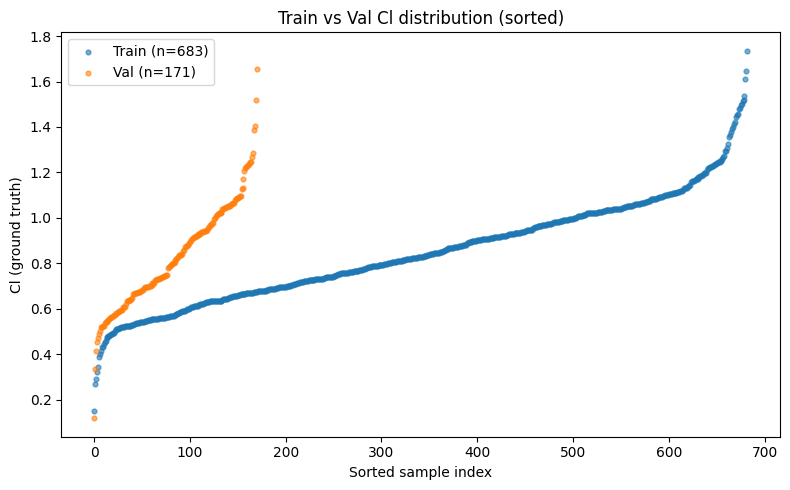

Train Cl: min=0.149, max=1.736, mean=0.849, std=0.2318
Val Cl:   min=0.118, max=1.653, mean=0.834, std=0.2373


In [ ]:
# Plot train vs val ground-truth Cl distributions to check for distribution mismatch
train_cl = [dataset.samples[i][1] for i in train_set.indices]
val_cl   = [dataset.samples[i][1] for i in val_set.indices]

plt.figure(figsize=(8, 5))
plt.scatter(range(len(train_cl)), sorted(train_cl), s=12, alpha=0.6, label=f'Train (n={len(train_cl)})', color='#1f77b4')
plt.scatter(range(len(val_cl)), sorted(val_cl), s=12, alpha=0.6, label=f'Val (n={len(val_cl)})', color='#ff7f0e')
plt.xlabel('Sorted sample index')
plt.ylabel('Cl (ground truth)')
plt.title('Train vs Val Cl distribution (sorted)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/train_val_cl_distribution_{RUN_NAME}.png', dpi=150)
plt.show()

print(f'Train Cl: min={min(train_cl):.3f}, max={max(train_cl):.3f}, mean={np.mean(train_cl):.3f}, std={np.std(train_cl):.4f}')
print(f'Val Cl:   min={min(val_cl):.3f}, max={max(val_cl):.3f}, mean={np.mean(val_cl):.3f}, std={np.std(val_cl):.4f}')

## Step 4 — Build the Model: ResNet-18 for Regression

In [ ]:
#resnet has many parameters, this optimizes all of them

# Load pretrained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all pretrained layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last block (layer4) so it can adapt to airfoil shapes
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer with dropout + linear regression head
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, 1)
)

model = model.to(device)
print('ResNet-18 loaded. Final layer:', model.fc)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

ResNet-18 loaded. Final layer: Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=1, bias=True)
)
Total parameters: 11,177,025
Trainable parameters: 8,394,241


## Step 5 — Train the Model

In [ ]:
EPOCHS    = 50
LR        = 1e-4
WEIGHT_DECAY = 1e-2

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)  # shape [B, 1]

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step()

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}')

print('\nTraining complete!')

Epoch   1/50 | Train MSE: 0.4516 | Val MSE: 0.0662
Epoch   2/50 | Train MSE: 0.4044 | Val MSE: 0.0470
Epoch   3/50 | Train MSE: 0.3128 | Val MSE: 0.0210
Epoch   4/50 | Train MSE: 0.2870 | Val MSE: 0.0281
Epoch   5/50 | Train MSE: 0.2540 | Val MSE: 0.0425
Epoch   6/50 | Train MSE: 0.2371 | Val MSE: 0.0190
Epoch   7/50 | Train MSE: 0.2001 | Val MSE: 0.0128
Epoch   8/50 | Train MSE: 0.1928 | Val MSE: 0.0201
Epoch   9/50 | Train MSE: 0.1515 | Val MSE: 0.0160
Epoch  10/50 | Train MSE: 0.1444 | Val MSE: 0.0118
Epoch  11/50 | Train MSE: 0.1485 | Val MSE: 0.0083
Epoch  12/50 | Train MSE: 0.1242 | Val MSE: 0.0117
Epoch  13/50 | Train MSE: 0.1280 | Val MSE: 0.0106
Epoch  14/50 | Train MSE: 0.1062 | Val MSE: 0.0113
Epoch  15/50 | Train MSE: 0.1082 | Val MSE: 0.0105
Epoch  16/50 | Train MSE: 0.1036 | Val MSE: 0.0098
Epoch  17/50 | Train MSE: 0.0869 | Val MSE: 0.0098
Epoch  18/50 | Train MSE: 0.0927 | Val MSE: 0.0084
Epoch  19/50 | Train MSE: 0.0812 | Val MSE: 0.0083
Epoch  20/50 | Train MSE: 0.083

## Step 6 — Plot Training Curves

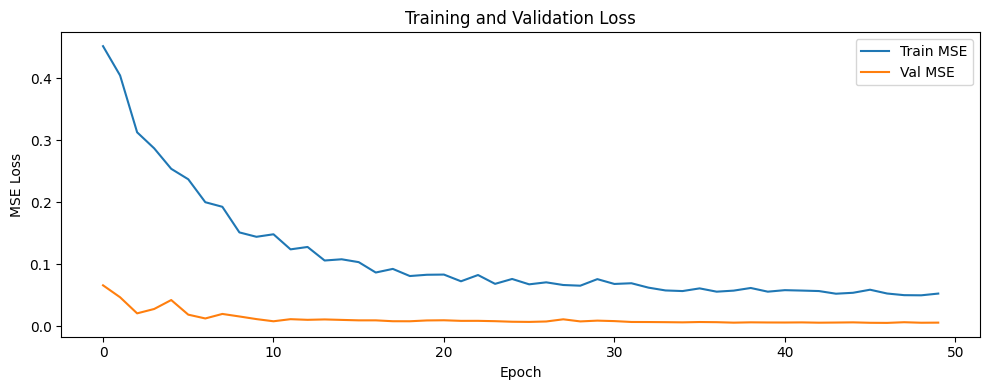

Saved to Drive: training_loss.png


In [ ]:
# visualization of how trained AI is and display of error margin change
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_loss_{RUN_NAME}.png', dpi=150)
plt.show()
print('Saved to Drive: training_loss.png')

## Step 7 — Scatter Plot: Actual XFOIL Lift vs Predicted Lift

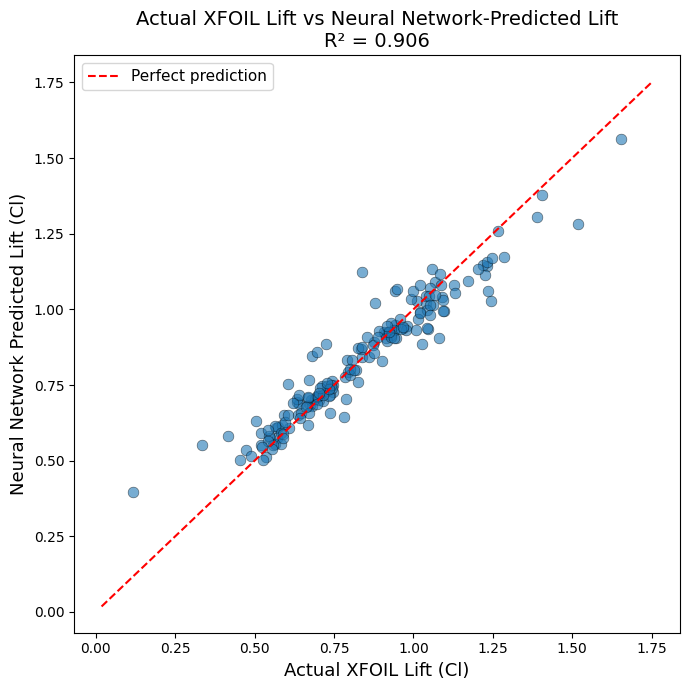

Val R² score: 0.9065
Saved to Drive: scatter_run13_dropout0.5_seed42.png
Train R²: 0.9552
Val R²:   0.9065
Gap (Train R² - Val R²): 0.0488


In [ ]:


model.eval()
all_actual    = []
all_predicted = []

with torch.no_grad():
    for images, labels in val_loader:
        images  = images.to(device)
        outputs = model(images).squeeze(1).cpu().numpy()
        actual  = labels.numpy()
        all_actual.extend(actual.tolist())
        all_predicted.extend(outputs.tolist())

all_actual    = np.array(all_actual)
all_predicted = np.array(all_predicted)

# Compute validation R² score
ss_res = np.sum((all_actual - all_predicted) ** 2)
ss_tot = np.sum((all_actual - np.mean(all_actual)) ** 2)
r2     = 1 - (ss_res / ss_tot)

# Plot
plt.figure(figsize=(7, 7))
plt.scatter(all_actual, all_predicted, alpha=0.6, edgecolors='k', linewidths=0.4, s=60)

lims = [min(all_actual.min(), all_predicted.min()) - 0.1,
        max(all_actual.max(), all_predicted.max()) + 0.1]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual XFOIL Lift (Cl)',    fontsize=13)
plt.ylabel('Neural Network Predicted Lift (Cl)', fontsize=13)
plt.title(f'Actual XFOIL Lift vs Neural Network-Predicted Lift\nR² = {r2:.3f}', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/scatter_{RUN_NAME}.png', dpi=150)
plt.show()
print(f'Val R² score: {r2:.4f}')
print(f'Saved to Drive: scatter_{RUN_NAME}.png')

# --- Also evaluate on training set for overfitting comparison ---
model.eval()
train_actual    = []
train_predicted = []

with torch.no_grad():
    for images, labels in train_loader:
        images  = images.to(device)
        outputs = model(images).squeeze(1).cpu().numpy()
        train_actual.extend(labels.numpy().tolist())
        train_predicted.extend(outputs.tolist())

train_actual    = np.array(train_actual)
train_predicted = np.array(train_predicted)

ss_res_train = np.sum((train_actual - train_predicted) ** 2)
ss_tot_train = np.sum((train_actual - np.mean(train_actual)) ** 2)
r2_train     = 1 - (ss_res_train / ss_tot_train)

print(f'Train R²: {r2_train:.4f}')
print(f'Val R²:   {r2:.4f}')
print(f'Gap (Train R² - Val R²): {r2_train - r2:.4f}')

## Step 8 — Save the Trained Model

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/resnet18_airfoil.pth')
print('Model saved to Drive: resnet18_airfoil.pth')

Model saved to Drive: resnet18_airfoil.pth
